In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
from mlxtend.preprocessing import TransactionEncoder
from tabulate import tabulate
import seaborn as sns

import collections
import warnings

import numpy as np
import pandas as pd

warnings.simplefilter("always", DeprecationWarning)

import random
import time

from itertools import groupby
import itertools

import math

In [2]:
# local file path
df = pd.read_csv('./market_basket_dataset.csv', sep=';', dtype={'BillNo': str}, low_memory=False)

# drop column unnamed (for general purpose)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

df


,BillNo,Itemname,Quantity,Price,CustomerID
0,1000,Apples,5,8.30,52299
1,1000,Butter,4,6.06,11752
2,1000,Eggs,4,2.66,16415
3,1000,Potatoes,4,8.10,22889
4,1004,Oranges,2,7.26,52255
...,...,...,...,...,...
19845,4999,Bananas,5,4.89,39862
19846,5000,Coffee,5,3.49,82041
19847,5000,Butter,3,6.92,82041
19848,5000,Sugar,2,5.75,82041


In [3]:
def drawLine(length=40):
    print("─" * length)

In [4]:
#pengecekan tipe data
drawLine()
print("📋 DATA TYPES")
drawLine()
print(df.dtypes.to_string())
drawLine()

# Menghitung jumlah itemname
jumlah_itemname = df['Itemname'].nunique()
print("\n📦  JUMLAH ITEMNAME")
drawLine()
print(f"Total unik: {jumlah_itemname:,}")
drawLine()

# Menghitung jumlah BillNo/transaksi
jumlah_billno = df['BillNo'].nunique()
print("\n🧾  JUMLAH BILLNO / TRANSAKSI")
drawLine()
print(f"Total unik: {jumlah_billno:,}")
drawLine()

# Menampilkan daftar BillNo/transaksi
billno_list = df['BillNo'].unique()
print("\n🧾  DAFTAR BILLNO")
drawLine()
cols = 20
rows = (len(billno_list) + cols - 1) // cols
for r in range(rows):
    line = []
    for c in range(cols):
        idx = r + c * rows
        if idx < len(billno_list):
            line.append(f"{idx + 1:>3}. {billno_list[idx]}")
        else:
            line.append(" " * 12)
    print("  ".join(line))
drawLine()


────────────────────────────────────────
📋 DATA TYPES
────────────────────────────────────────
BillNo         object
Itemname       object
Quantity        int64
Price         float64
CustomerID      int64
────────────────────────────────────────

📦  JUMLAH ITEMNAME
────────────────────────────────────────
Total unik: 19
────────────────────────────────────────

🧾  JUMLAH BILLNO / TRANSAKSI
────────────────────────────────────────
Total unik: 3,656
────────────────────────────────────────

🧾  DAFTAR BILLNO
────────────────────────────────────────
  1. 1000  184. 1528  367. 1711  550. 1894  733. 2077  916. 2260  1099. 2443  1282. 2626  1465. 2809  1648. 2992  1831. 3175  2014. 3358  2197. 3541  2380. 3724  2563. 3907  2746. 4090  2929. 4273  3112. 4456  3295. 4639  3478. 4822
  2. 1004  185. 1529  368. 1712  551. 1895  734. 2078  917. 2261  1100. 2444  1283. 2627  1466. 2810  1649. 2993  1832. 3176  2015. 3359  2198. 3542  2381. 3725  2564. 3908  2747. 4091  2930. 4274  3113. 4457  3296.

In [5]:
# Pengecekan nilai kosong
drawLine()
print("🔍 Pengecekan Nilai Kosong (Missing Values)")
drawLine()
print(df.isnull().sum())

# Menampilkan Baris yang Mengandung Nilai Kosong (NaN)
print("\n")
drawLine()
print("⚠️  Baris yang Mengandung Nilai Kosong (NaN)")
drawLine()
print(df[df.isnull().any(axis=1)])

────────────────────────────────────────
🔍 Pengecekan Nilai Kosong (Missing Values)
────────────────────────────────────────
BillNo        0
Itemname      0
Quantity      0
Price         0
CustomerID    0
dtype: int64


────────────────────────────────────────
⚠️  Baris yang Mengandung Nilai Kosong (NaN)
────────────────────────────────────────
Empty DataFrame
Columns: [BillNo, Itemname, Quantity, Price, CustomerID]
Index: []


In [6]:
# Normalisasi nama barang ke huruf kecil
df['Itemname'] = df['Itemname'].str.lower()

# Mengelompokkan barang per transaksi (BillNo) 
transactions = df.groupby('BillNo')['Itemname'].apply(list).tolist()

# Tampilkan keranjang transaksi hasil pengelompokan
print("\n🛒  Keranjang Transaksi (setiap daftar = satu struk):\n")
# Build a clean table
table = [(f"T{idx:03d}", ", ".join(basket)) for idx, basket in enumerate(transactions, 1)]
print(tabulate(table, headers=["Transaksi", "Daftar Barang"], tablefmt="grid"))



🛒  Keranjang Transaksi (setiap daftar = satu struk):

+-------------+---------------------------------------------------------------------------------------------------+
| Transaksi   | Daftar Barang                                                                                     |
+=============+===================================================================================================+
| T001        | apples, butter, eggs, potatoes                                                                    |
+-------------+---------------------------------------------------------------------------------------------------+
| T002        | oranges                                                                                           |
+-------------+---------------------------------------------------------------------------------------------------+
| T003        | milk, onions, cereal                                                                              |
+-------------+--

# Tabu Search Preprocessing

In [7]:
# Fungsi Tabu Search (jalankan sebelum FP-Growth)
def tabu_search(transactions, max_iter=15, tabu_size=5, k=5, threshold=0.5):
    """
    Tabu Search untuk memilih k item fokus dari transaksi dan mem-filter
    transaksi sebelum FP-Growth.

    Args:
        transactions (List[List[str]]): daftar transaksi (list item per struk)
        max_iter (int): jumlah iterasi maksimal
        tabu_size (int): ukuran tabu list (tenure)
        k (int): jumlah item fokus yang dipilih
        threshold (float): minimum support relatif (0..1) untuk kandidat item

    Returns:
        dict: {
          'selected_items': List[str],
          'filtered_transactions': List[List[str]],
          'score': float
        }
    """
    from collections import Counter, deque
    from itertools import combinations

    n = len(transactions)
    if n == 0:
        return {'selected_items': [], 'filtered_transactions': [], 'score': 0.0}

    # Gunakan set per transaksi untuk menghitung presence dengan benar
    trx_sets = [set(t) for t in transactions]

    # Support single items (presence-based)
    item_counts = Counter()
    for s in trx_sets:
        item_counts.update(s)
    item_support = {it: item_counts[it] / n for it in item_counts}

    # Support pasangan (co-occurrence presence-based)
    pair_counts = Counter()
    for s in trx_sets:
        for a, b in combinations(sorted(s), 2):
            pair_counts[(a, b)] += 1
    pair_support = {p: pair_counts[p] / n for p in pair_counts}

    # Kandidat awal berdasar threshold; fallback jika kosong
    universe = [it for it, sup in item_support.items() if sup >= threshold]
    if not universe:
        universe = [it for it, _ in item_counts.most_common()]

    # Inisialisasi solusi dengan top-k by support
    init = [it for it, _ in sorted(((it, item_support[it]) for it in universe),
                                   key=lambda x: (-x[1], x[0]))][:k]
    S = set(init)

    # Objective: gabungan support rata-rata dan ko-occurrence internal
    def score_set(Sset):
        if not Sset:
            return 0.0
        Slist = sorted(Sset)
        s1 = sum(item_support.get(it, 0.0) for it in Slist) / k
        if len(Slist) >= 2 and k >= 2:
            pairs = list(combinations(Slist, 2))
            denom_pairs = (k * (k - 1)) / 2
            s2 = sum(pair_support.get(tuple(sorted(p)), 0.0) for p in pairs)
            s2 = s2 / denom_pairs
        else:
            s2 = 0.0
        return 0.6 * s1 + 0.4 * s2

    best_S = set(S)
    best_score = score_set(best_S)

    tabu = deque(maxlen=tabu_size)

    for iter_count in range(max_iter):
        current_best_neighbor = None
        current_best_move = None
        current_best_score = -1.0

        # Generate neighbors: add/remove/swap
        # ADD
        if len(S) < k:
            for x in universe:
                if x in S:
                    continue
                move_token = ("add", x)
                cand = set(S)
                cand.add(x)
                sc = score_set(cand)
                if move_token in tabu and sc <= best_score:
                    continue  # tabu, no aspiration
                if sc > current_best_score:
                    current_best_score = sc
                    current_best_neighbor = cand
                    current_best_move = move_token

        # REMOVE
        for i in list(S):
            move_token = ("remove", i)
            cand = set(S)
            cand.remove(i)
            sc = score_set(cand)
            if move_token in tabu and sc <= best_score:
                continue
            if sc > current_best_score:
                current_best_score = sc
                current_best_neighbor = cand
                current_best_move = move_token

        # SWAP
        for i in list(S):
            for x in universe:
                if x in S:
                    continue
                move_token = ("swap", i, x)
                cand = set(S)
                cand.discard(i)
                cand.add(x)
                sc = score_set(cand)
                if move_token in tabu and sc <= best_score:
                    continue
                if sc > current_best_score:
                    current_best_score = sc
                    current_best_neighbor = cand
                    current_best_move = move_token

        # Jika tak ada neighbor valid, berhenti
        if current_best_neighbor is None:
            print(f"[iter {iter_count}] no valid neighbor, stopping")
            break

        # Apply move
        S = current_best_neighbor
        tabu.append(current_best_move)

        # Update best (global)
        if current_best_score > best_score:
            best_S = set(S)
            best_score = current_best_score
            print(f"[iter {iter_count}] new best score={best_score:.4f} move={current_best_move}")
        else:
            print(f"[iter {iter_count}] accepted move={current_best_move} score={current_best_score:.4f}")

    # Filter transaksi ke item terpilih
    selected_items = sorted(best_S)
    filtered = []
    for t in transactions:
        print(f"[debug] t={t}")
        ft = [it for it in t if it in best_S]
        if ft:
            filtered.append(ft)

    return {
        'selected_items': selected_items,
        'filtered_transactions': filtered,
        'score': best_score
    }

In [8]:
df['Itemname'] = df['Itemname'].str.lower()

# Mengelompokkan barang per transaksi (BillNo)
transactions = df.groupby('BillNo')['Itemname'].apply(list).tolist()

In [9]:
tabu_out = tabu_search(transactions, max_iter=100, tabu_size=18, k=50, threshold=0.1)

transactions_tabu = tabu_out['filtered_transactions']
selected_items = tabu_out['selected_items']
print("\n🔧 Tabu Search: item terpilih →", ", ".join(selected_items))
print(f"Total transaksi setelah filter: {len(transactions_tabu)} dari {len(transactions)}")

[iter 0] accepted move=('remove', 'eggs') score=0.0676
[iter 1] accepted move=('add', 'eggs') score=0.0696
[iter 2] accepted move=('remove', 'juice') score=0.0676
[iter 3] accepted move=('add', 'juice') score=0.0696
[iter 4] accepted move=('remove', 'milk') score=0.0661
[iter 5] accepted move=('add', 'milk') score=0.0696
[iter 6] accepted move=('remove', 'cereal') score=0.0661
[iter 7] accepted move=('add', 'cereal') score=0.0696
[iter 8] accepted move=('remove', 'tea') score=0.0661
[iter 9] accepted move=('add', 'tea') score=0.0696
[iter 10] accepted move=('remove', 'yogurt') score=0.0661
[iter 11] accepted move=('add', 'yogurt') score=0.0696
[iter 12] accepted move=('remove', 'onions') score=0.0661
[iter 13] accepted move=('add', 'onions') score=0.0696
[iter 14] accepted move=('remove', 'pasta') score=0.0661
[iter 15] accepted move=('add', 'pasta') score=0.0696
[iter 16] accepted move=('remove', 'bread') score=0.0660
[iter 17] accepted move=('add', 'bread') score=0.0696
[iter 18] acc

### Benchmark Tabu Search Algorithm

In [10]:
def benchmark_tabu_search(transactions, sizes=None, repeats=5, max_iter=15, tabu_size=5, k=5, threshold=0.5, seed=42):
    random.seed(seed)
    n_total = len(transactions)
    if n_total == 0:
        raise ValueError("transactions kosong; pastikan sudah dibuat dari df.")

    # Default ukuran: 5%, 10%, 20%, 33%, 50%, 75%, 100% dari jumlah transaksi
    if sizes is None:
        sizes = sorted(set([max(1, int(n_total * r)) for r in [0.05, 0.1, 0.2, 0.33, 0.5, 0.75, 1.0]]))
    sizes = [s for s in sizes if 1 <= s <= n_total]

    rows = []
    for n in sizes:
        times = []
        last_out = None
        for _ in range(repeats):
            sample = transactions if n == n_total else random.sample(transactions, n)
            start = time.perf_counter()
            out = tabu_search(sample, max_iter=max_iter, tabu_size=tabu_size, k=k, threshold=threshold)
            elapsed = time.perf_counter() - start
            times.append(elapsed)
            last_out = out

        rows.append({
            'n_transactions': n,
            'time_sec_median': float(np.median(times)),
            'time_sec_mean': float(np.mean(times)),
            'time_sec_min': float(np.min(times)),
            'time_sec_max': float(np.max(times)),
            'selected_items_count': len(last_out.get('selected_items', [])),
            'filtered_transactions_count': len(last_out.get('filtered_transactions', [])),
            'score': float(last_out.get('score', 0.0))
        })

    return pd.DataFrame(rows).sort_values('n_transactions')

────────────────────────────────────────
⏱️ Benchmark Tabu Search vs Ukuran Dataset
────────────────────────────────────────
[iter 0] accepted move=('remove', 'bananas') score=0.0000
[iter 1] accepted move=('add', 'bananas') score=0.0607
[iter 2] no valid neighbor, stopping
[debug] t=['oranges', 'sugar', 'coffee', 'chicken', 'tea', 'juice', 'pasta']
[debug] t=['apples', 'bananas', 'oranges', 'cheese']
[debug] t=['oranges', 'cheese']
[debug] t=['cheese', 'pasta', 'bananas', 'tomatoes', 'potatoes']
[debug] t=['sugar', 'yogurt', 'coffee', 'tea', 'milk']
[debug] t=['tomatoes', 'apples', 'yogurt', 'bananas']
[debug] t=['apples', 'yogurt', 'pasta', 'chicken', 'cereal', 'bread', 'bananas']
[debug] t=['oranges', 'apples', 'bananas', 'potatoes']
[debug] t=['bananas', 'cereal', 'milk']
[debug] t=['potatoes', 'tomatoes', 'onions']
[debug] t=['pasta', 'onions', 'cheese', 'tomatoes']
[debug] t=['milk', 'bananas', 'oranges', 'butter', 'cereal']
[debug] t=['milk', 'cereal', 'eggs', 'bananas']
[debug]

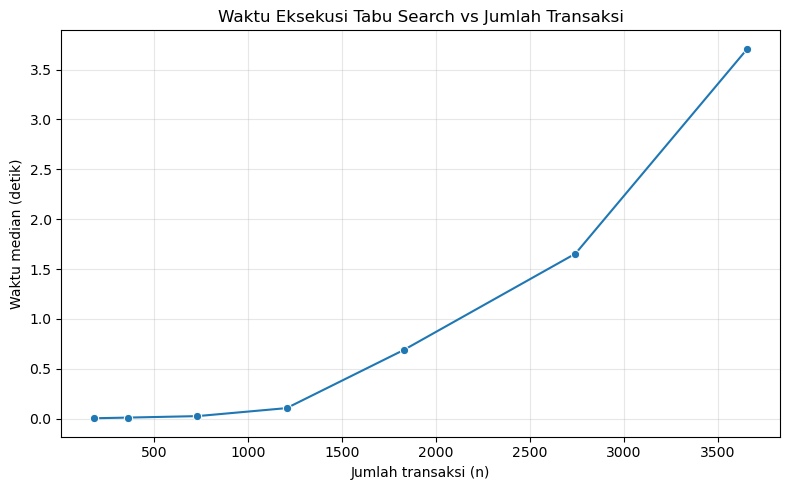

In [11]:
# Pastikan 'transactions' ada; jika belum, buat dari df
if 'transactions' not in globals():
    df['Itemname'] = df['Itemname'].str.lower()
    transactions = df.groupby('BillNo')['Itemname'].apply(list).tolist()

# Jalankan benchmark
drawLine()
print("⏱️ Benchmark Tabu Search vs Ukuran Dataset")
drawLine()
bench_df = benchmark_tabu_search(transactions, repeats=5, max_iter=15, tabu_size=5, k=5, threshold=0.5, seed=42)
print(tabulate(bench_df, headers='keys', tablefmt='grid', showindex=False))

# Plot hasil
plt.figure(figsize=(8, 5))
sns.lineplot(data=bench_df, x='n_transactions', y='time_sec_median', marker='o')
plt.title('Waktu Eksekusi Tabu Search vs Jumlah Transaksi')
plt.xlabel('Jumlah transaksi (n)')
plt.ylabel('Waktu median (detik)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# Encode transaksi ke format biner
te = TransactionEncoder()
te_ary = te.fit(transactions_tabu).transform(transactions_tabu)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

# Tampilan hasil data encoding
drawLine()
print("TRANSACTION ENCODER RESULTS - BINARY FORMAT")
drawLine()
print(f"Dataset Shape: {df_encoded.shape[0]} transaksi × {df_encoded.shape[1]} item")
print("\n10 Data Pertama:")
drawLine()

print(tabulate(df_encoded.head(10), headers='keys', tablefmt='grid', showindex=True)) # 1 = True, 0 = False

────────────────────────────────────────
TRANSACTION ENCODER RESULTS - BINARY FORMAT
────────────────────────────────────────
Dataset Shape: 3656 transaksi × 19 item

10 Data Pertama:
────────────────────────────────────────
+----+----------+-----------+---------+----------+----------+----------+-----------+----------+--------+---------+--------+----------+-----------+---------+------------+---------+-------+------------+----------+
|    |   apples |   bananas |   bread |   butter |   cereal |   cheese |   chicken |   coffee |   eggs |   juice |   milk |   onions |   oranges |   pasta |   potatoes |   sugar |   tea |   tomatoes |   yogurt |
+====+==========+===========+=========+==========+==========+==========+===========+==========+========+=========+========+==========+===========+=========+============+=========+=======+============+==========+
|  0 |        1 |         0 |       0 |        1 |        0 |        0 |         0 |        0 |      1 |       0 |      0 |        0 |     

## Manual Algorithm FP Growth

### Configure FP Common Algorithm

In [13]:
def setup_fptree(df, min_support):
    """
    Membangun struktur FP-Tree dari DataFrame transaksi.
    
    Langkah-langkah:
    1. Hitung jumlah transaksi (baris).
    2. Deteksi apakah DataFrame dalam format sparse.
    3. Buat matriks 'disabled' untuk menandai nilai yang hilang (NaN) atau tidak valid.
    4. Hitung support relatif setiap item dengan mengabaikan baris yang disabled.
    5. Filter item yang memenuhi min_support.
    6. Urutkan item berdasarkan support (descending) untuk pembangunan tree.
    7. Bangun FP-Tree dengan memasukkan setiap transaksi yang sudah difilter dan diurutkan.
    
    Returns:
        tree: objek FPTree yang sudah terisi
        disabled: ndarray penanda baris/item yang tidak valid
        rank: dict pemetaan item ke urutan prioritas
    """
    num_itemsets = len(df.index)

    # Deteksi format sparse
    is_sparse = False
    if hasattr(df, "sparse"):
        if df.size == 0:
            itemsets = df.values
        else:
            itemsets = df.sparse.to_coo().tocsr()
            is_sparse = True
    else:
        itemsets = df.values

    # Buat masker untuk nilai yang hilang / tidak valid
    disabled = df.copy()
    disabled = np.where(pd.isna(disabled), 1, np.nan) + np.where(
        (disabled == 0) | (disabled == 1), np.nan, 0
    )

    # Hitung support tiap item dengan mengabaikan baris disabled
    item_support = np.array(
        np.nansum(df.values, axis=0)
        / (float(num_itemsets) - np.nansum(disabled, axis=0))
    )
    item_support = item_support.reshape(-1)
    items = np.nonzero(item_support >= min_support)[0]

    # Urutkan item berdasarkan support (descending)
    indices = item_support[items].argsort()
    rank = {item: i for i, item in enumerate(items[indices])}

    # Hapus nilai nol pada sparse matrix untuk efisiensi
    if is_sparse:
        itemsets.eliminate_zeros()

    # Bangun FP-Tree
    tree = FPTree(rank)
    for i in range(num_itemsets):
        if is_sparse:
            nonnull = itemsets.indices[itemsets.indptr[i] : itemsets.indptr[i + 1]]
        else:
            nonnull = np.where(itemsets[i, :])[0]
        # Filter item yang memenuhi min_support lalu urutkan sesuai rank
        itemset = [item for item in nonnull if item in rank]
        itemset.sort(key=rank.get, reverse=True)
        tree.insert_ordered_itemset(itemset)

    return tree, disabled, rank


def generate_itemsets_with_supports(generator, df, disabled, min_support, num_itemsets, colname_map):
    """
    Menghasilkan daftar itemset beserta nilai support-nya dari generator pola yang ditemukan.
    
    Langkah-langkah:
    1. Iterasi setiap (support, itemset) dari generator.
    2. Hitung support yang sudah dikoreksi dengan mengabaikan baris disabled.
       - Untuk itemset tunggal: langsung kurangi jumlah disabled.
       - Untuk itemset >1: periksa tiap baris, hitung penyebut (baris yang valid) dan pembilang (itemset yang valid).
    3. Filter hasil akhir yang memenuhi min_support.
    4. (Opsional) ubah nama kolom sesuai pemetaan yang diberikan.
    
    Returns:
        DataFrame dengan kolom 'support' dan 'itemsets'
    """
    itemsets = []
    supports = []
    for sup, iset in generator:
        itemsets.append(frozenset(iset))
        dec = disabled[:, iset]
        _dec = df.values[:, iset]

        if len(iset) == 1:
            supports.append((sup - np.nansum(dec)) / (num_itemsets - np.nansum(dec)))

        elif len(iset) > 1:
            denom = 0
            num = 0
            for i in range(dec.shape[0]):
                item_dsbl = list(dec[i, :])
                item_orig = list(_dec[i, :])

                if 1 in set(item_dsbl):
                    denom += 1

                    if (0 not in set(item_orig)) or (
                        all(np.isnan(x) for x in item_orig)
                    ):
                        num -= 1

            if num_itemsets - denom == 0:
                supports.append(0)
            else:
                supports.append((sup + num) / (num_itemsets - denom))

    res_df = pd.DataFrame({"support": supports, "itemsets": itemsets})
    res_df = res_df[res_df["support"] >= min_support]

    if colname_map is not None:
        res_df["itemsets"] = res_df["itemsets"].apply(
            lambda x: frozenset([colname_map[i] for i in x])
        )

    return res_df


def check_valid_input(df, null_values=False):
    """
    Validasi keabsahan DataFrame input.
    
    Langkah-langkah:
    1. Lewati jika df None.
    2. Tolak SparseDataFrame yang sudah deprecated.
    3. Untuk sparse matrix, pastikan nama kolom string atau dimulai 0.
    4. Periksa tipe data: semua kolom harus boolean (atau boleh NaN bila null_values=True).
    5. Beri peringatan jika ada tipe non-bool.
    6. Pastikan nilai hanya 0, 1, True, False, (dan NaN bila null_values=True).
    
    Raises:
        TypeError, ValueError bila input tidak valid.
    """
    if df is None:
        return

    # Blokir SparseDataFrame deprecated
    if f"{type(df)}" == "<class 'pandas.core.frame.SparseDataFrame'>":
        msg = (
            "SparseDataFrame sudah kedaluwarsa. Gunakan DataFrame biasa dengan kolom sparse."
        )
        raise TypeError(msg)

    if df.size == 0:
        return
    if hasattr(df, "sparse"):
        if not isinstance(df.columns[0], str) and df.columns[0] != 0:
            raise ValueError(
                "Pembatasan Pandas: nama kolom bertipe int harus diawali 0 atau ubah jadi string: "
                "`df.columns = [str(i) for i in df.columns]`."
            )

    # Cek tipe data: semua boolean (ataboleh NaN bila null_values=True)
    if null_values:
        all_bools = (
            df.apply(lambda col: col.apply(lambda x: pd.isna(x) or isinstance(x, bool)))
            .all()
            .all()
        )
    else:
        all_bools = df.dtypes.apply(pd.api.types.is_bool_dtype).all()

    if not all_bools:
        warnings.warn(
            "Tipe data non-bool memperlambat komputasi. "
            "Gunakan DataFrame bertipe bool.",
            DeprecationWarning,
        )

        has_nans = pd.isna(df).any().any()
        if null_values and not has_nans:
            warnings.warn(
                "null_values=True lambat bila tak ada NaN. Gunakan False."
            )
        if not null_values and has_nans:
            raise ValueError(
                "NaN values are not permitted"
            )

        # Ambil nilai aktual untuk dicek
        if hasattr(df, "sparse"):
            if df.size == 0:
                values = df.values
            else:
                values = df.sparse.to_coo().tocoo().data
        else:
            values = df.values

        if null_values:
            idxs = np.where((values != 1) & (values != 0) & (~np.isnan(values)))
        else:
            idxs = np.where((values != 1) & (values != 0))

        if len(idxs[0]) > 0:
            val = values[tuple(loc[0] for loc in idxs)]
            s = (
                "The allowed values for a DataFrame"
                " are True, False, 0, 1. Found value %s" % (val)
            )

            if null_values:
                s = (
                    "The allowed values for a DataFrame"
                    " are True, False, 0, 1, NaN. Found value %s" % (val)
                )
            raise ValueError(s)


class FPTree(object):
    """
    Struktur data FP-Tree untuk menyimpan transaksi dalam bentuk pohon.
    Setiap node merepresentasikan item dengan count tertentu.
    """
    def __init__(self, rank=None):
        # Root node virtual (item=None)
        self.root = FPNode(None)
        # Dictionary menampung daftar node per item
        self.nodes = collections.defaultdict(list)
        # Item kondisi untuk conditional tree
        self.cond_items = []
        # Urutan prioritas item (support descending)
        self.rank = rank

    def conditional_tree(self, cond_item, minsup):
        """
        Bangun conditional FP-Tree untuk item tertentu.
        
        Langkah-langkah:
        1. Kumpulkan semua path dari root ke node cond_item.
        2. Hitung count tiap item pada path-path tersebut.
        3. Filter item yang memenuhi minsup.
        4. Bangun conditional tree baru dengan item yang sudah difilter & diurutkan.
        
        Returns:
            FPTree baru yang dikondisikan pada cond_item
        """
        branches = []
        count = collections.defaultdict(int)
        for node in self.nodes[cond_item]:
            branch = node.get_item_path_from_root()
            branches.append(branch)
            for item in branch:
                count[item] += node.count

        # Item yang memenuhi minsup, diurutkan ascending (untuk kemudahan)
        items = [item for item in count if count[item] >= minsup]
        items.sort(key=count.get)
        rank = {item: i for i, item in enumerate(items)}

        # Bangun conditional tree
        cond_tree = FPTree(rank)
        for idx, branch in enumerate(branches):
            branch = sorted(
                [i for i in branch if i in rank], key=rank.get, reverse=True
            )
            cond_tree.insert_ordered_itemset(branch, self.nodes[cond_item][idx].count)
        cond_tree.cond_items = self.cond_items + [cond_item]

        return cond_tree

    def insert_ordered_itemset(self, itemset, count=1):
        """
        Masukkan itemset (urutan menurun support) ke dalam tree.
        
        Langkah-langkah:
        1. Naikkan count root.
        2. Untuk setiap item, jika child sudah ada naikkan count, jika tidak buat node baru.
        3. Simpan node pada dictionary nodes untuk akses cepat.
        """
        self.root.count += count

        if len(itemset) == 0:
            return

        index = 0
        node = self.root
        for item in itemset:
            if item in node.children:
                child = node.children[item]
                child.count += count
                node = child
                index += 1
            else:
                break

        # Sisanya buat cabang baru
        for item in itemset[index:]:
            child_node = FPNode(item, count, node)
            self.nodes[item].append(child_node)
            node = child_node

    def is_single_path(self):
        """
        Cek apakah tree hanya berisi satu path lurus (untuk optimasi mining).
        
        Returns:
            bool: True bila tree hanya satu jalur dari root ke leaf
        """
        if len(self.root.children) > 1:
            return False
        for i in self.nodes:
            if len(self.nodes[i]) > 1 or len(self.nodes[i][0].children) > 1:
                return False
        return True

    def print_status(self, count, colnames):
        """
        Cetak status proses mining untuk debugging.
        
        Args:
            count: jumlah itemset yang sudah ditemukan
            colnames: dict pemetaan index ke nama kolom
        """
        cond_items = [str(i) for i in self.cond_items]
        if colnames:
            cond_items = [str(colnames[i]) for i in self.cond_items]
        cond_items = ", ".join(cond_items)
        print(
            "\r%d itemset dari tree yang dikondisikan pada item (%s)" % (count, cond_items),
            end="\n",
        )


class FPNode(object):
    """
    Node individual di dalam FP-Tree.
    """
    def __init__(self, item, count=0, parent=None):
        self.item = item          # Nama item (None untuk root)
        self.count = count        # Jumlah transaksi yang melewati node ini
        self.parent = parent      # Node induk
        self.children = collections.defaultdict(FPNode)  # Child nodes

        if parent is not None:
            parent.children[item] = self

    def get_item_path_from_root(self):
        """
        Ambil path item dari root (tidak termasuk node ini) dalam urutan root -> ... -> parent.
        
        Returns:
            list: item-item pada jalur, sudah diurutkan dari root
        """
        path = []
        if self.item is None:
            return path

        node = self.parent
        while node.item is not None:
            path.append(node.item)
            node = node.parent

        path.reverse()
        return path

### Configure FP Growth Algorithm

In [14]:
def fpgrowth(
    df, min_support=0.5, null_values=False, use_colnames=False, max_len=None, verbose=0
):
    # Langkah 1: Validasi DataFrame masukan dan flag penanganan nilai null
    check_valid_input(df, null_values)

    # Langkah 2: Pastikan min_support berada dalam rentang yang valid (0, 1]
    if min_support <= 0.0:
        raise ValueError(
            "`min_support` harus angka positif "
            "dalam interval `(0, 1]`. "
            "Didapat %s." % min_support
        )

    # Langkah 3: Bangun pemetaan nama kolom jika pengguna ingin menyimpan nama kolom asli
    colname_map = None
    if use_colnames:
        colname_map = {idx: item for idx, item in enumerate(df.columns)}

    # Langkah 4: Bangun FP-tree dan identifikasi item yang dinonaktifkan (di bawah min_support)
    tree, disabled, _ = setup_fptree(df, min_support)

    # Langkah 5: Ubah min_support relatif menjadi hitungan absolut
    minsup = math.ceil(min_support * len(df.index))

    # Langkah 6: Buat generator yang secara malas menghasilkan itemset yang sering
    generator = fpg_step(tree, minsup, colname_map, max_len, verbose)

    # Langkah 7: Pasca-proses generator untuk melampirkan nilai support dan kembalikan hasil akhir
    return generate_itemsets_with_supports(
        generator, df, disabled, min_support, len(df.index), colname_map
    )


def fpg_step(tree, minsup, colnames, max_len, verbose):
    # Langkah 1: Inisialisasi penghitung untuk itemset yang dihasilkan dan ambil item tree saat ini
    count = 0
    items = tree.nodes.keys()

    # Langkah 2: Tangani kasus khusus ketika FP-tree berupa jalur tunggal
    if tree.is_single_path():
        # Tentukan ukuran kombinasi maksimal dengan memperhatikan batasan max_len
        size_remain = len(items) + 1
        if max_len:
            size_remain = max_len - len(tree.cond_items) + 1
        # Hasilkan semua kombinasi non-kosong dari item pada jalur
        for i in range(1, size_remain):
            for itemset in itertools.combinations(items, i):
                count += 1
                # Kombinasi adalah hitungan minimum dari item-itemnya
                support = min([tree.nodes[i][0].count for i in itemset])
                yield support, tree.cond_items + list(itemset)

    # Langkah 3: Jika tree bukan jalur tunggal, hasilkan setiap perluasan item
    elif not max_len or max_len > len(tree.cond_items):
        for item in items:
            count += 1
            # Agregasikan support untuk item di semua nodenya
            support = sum([node.count for node in tree.nodes[item]])
            yield support, tree.cond_items + [item]

    # Langkah 4: print
    if verbose:
        tree.print_status(count, colnames)

    # Langkah 5: Secara rekursif jalankan FP-tree bersyarat untuk setiap item
    if not tree.is_single_path() and (not max_len or max_len > len(tree.cond_items)):
        for item in items:
            # Bangun FP-tree bersyarat untuk item saat ini
            cond_tree = tree.conditional_tree(item, minsup)
            # Secara rekursif hasilkan itemset yang sering dari tree bersyarat
            for sup, iset in fpg_step(cond_tree, minsup, colnames, max_len, verbose):
                yield sup, iset

### Implementation FP Growth


Hasil Frequent Itemset dengan nilai support: 

         support                                     itemsets
0      0.376641                                     (apples)
1      0.265864                                   (potatoes)
2      0.262309                                     (butter)
3      0.142505                                       (eggs)
4      0.265317                                    (oranges)
...         ...                                          ...
11647  0.001641         (tea, juice, bananas, yogurt, bread)
11648  0.001094            (tea, juice, milk, yogurt, bread)
11649  0.001094          (tea, juice, bread, sugar, chicken)
11650  0.001094         (tea, juice, coffee, bread, chicken)
11651  0.001094  (tea, juice, coffee, bread, sugar, chicken)

[11652 rows x 2 columns]


/var/folders/qk/p1xn12n13qb82ww1m9ffhlkm0000gn/T/ipykernel_38793/1440687802.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='support', y='itemsets', data=frequent_itemsets_sorted, palette='viridis')


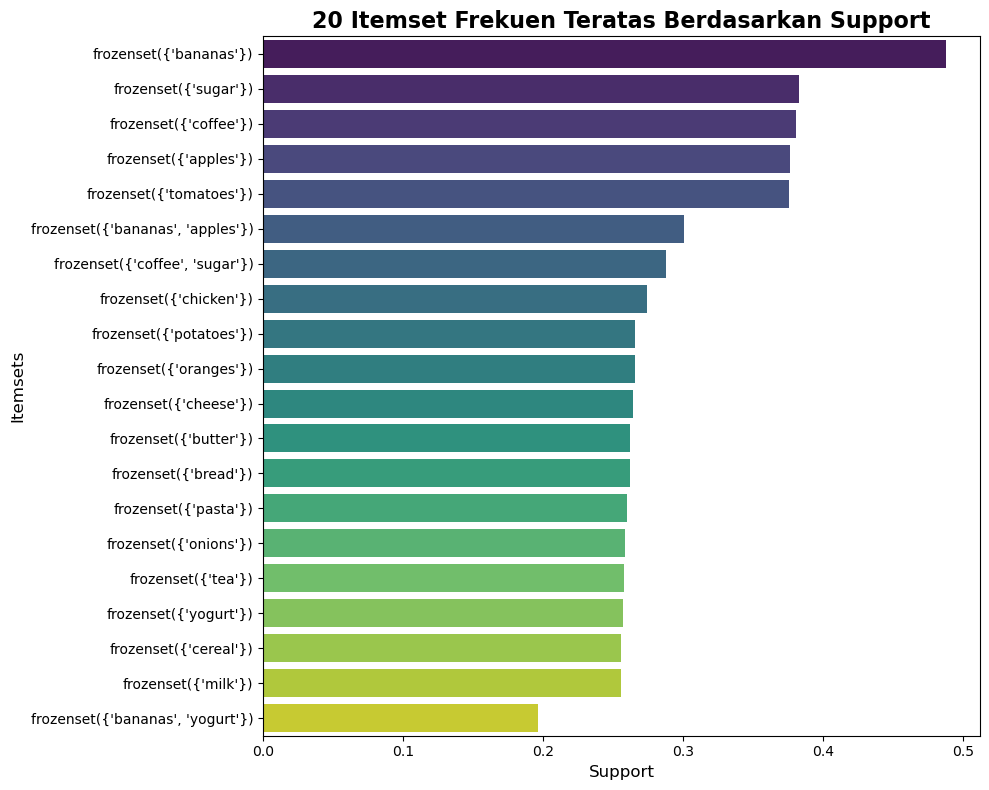

In [15]:
# Hitung frequent itemsets dengan nilai support
frequent_itemsets = fpgrowth(df_encoded, min_support=0.001, use_colnames=True)
print("\nHasil Frequent Itemset dengan nilai support: \n\n", frequent_itemsets)

frequent_itemsets_sorted = frequent_itemsets.sort_values(by='support', ascending=False).head(20)
# Grafik Horizontal
plt.figure(figsize=(10, 8))
sns.barplot(x='support', y='itemsets', data=frequent_itemsets_sorted, palette='viridis')
plt.title('20 Itemset Frekuen Teratas Berdasarkan Support', fontsize=16, fontweight='bold')
plt.xlabel('Support', fontsize=12)
plt.ylabel('Itemsets', fontsize=12)
plt.tight_layout()
plt.show()


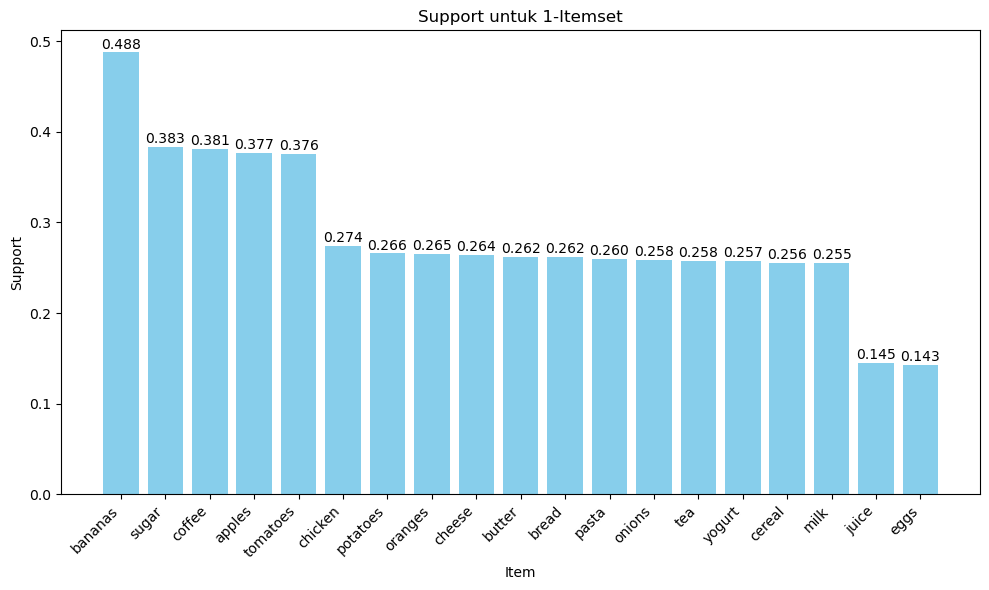

In [16]:
# mengurutkan berdasarkan prioritas 1-itemset
single_items = frequent_itemsets[frequent_itemsets['itemsets'].apply(lambda x: len(x) == 1)]

single_items_sorted = single_items.sort_values(by='support', ascending=False)

# Menampilkan grafik batang dengan keterangan
import matplotlib.pyplot as plt

labels = [list(item)[0] for item in single_items_sorted['itemsets']]
supports = single_items_sorted['support'].values

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, supports, color='skyblue')

# Keterangan
plt.xlabel('Item')
plt.ylabel('Support')
plt.title('Support untuk 1-Itemset')
plt.xticks(rotation=45, ha='right')

for bar, sup in zip(bars, supports):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{sup:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


### Benchmark waktu eksekusi fpgrowth

In [17]:
def benchmark_fpgrowth(df_binary, sizes=None, repeats=5, min_support=0.01, max_len=None, use_colnames=True, seed=42, verbose=0):
    random.seed(seed)
    n_total = len(df_binary.index)
    if n_total == 0:
        raise ValueError("df_binary kosong; pastikan sudah hasil encoding transaksi.")

    # Default ukuran: 5%, 10%, 20%, 33%, 50%, 75%, 100% dari jumlah transaksi
    if sizes is None:
        sizes = sorted(set([max(1, int(n_total * r)) for r in [0.05, 0.1, 0.2, 0.33, 0.5, 0.75, 1.0]]))
    sizes = [s for s in sizes if 1 <= s <= n_total]

    rows = []
    rng = random.Random(seed)

    for n in sizes:
        times = []
        n_itemsets_last = 0
        max_len_last = 0

        for _ in range(repeats):
            rs = rng.randint(0, 10**9)
            sample_df = df_binary.sample(n, random_state=rs)
            sample_df_bool = sample_df.astype(bool)

            start = time.perf_counter()
            res = fpgrowth(
                sample_df_bool,
                min_support=min_support,
                use_colnames=use_colnames,
                max_len=max_len,
                verbose=verbose
            )
            elapsed = time.perf_counter() - start

            times.append(elapsed)
            n_itemsets_last = int(len(res))
            max_len_last = int(res["itemsets"].apply(len).max()) if len(res) else 0

        rows.append({
            "n_transactions": n,
            "time_sec_median": float(np.median(times)),
            "time_sec_mean": float(np.mean(times)),
            "time_sec_min": float(np.min(times)),
            "time_sec_max": float(np.max(times)),
            "n_itemsets": n_itemsets_last,
            "max_itemset_len": max_len_last
        })

    return pd.DataFrame(rows).sort_values("n_transactions")

────────────────────────────────────────
⏱️ Benchmark FP-Growth vs Ukuran Dataset
────────────────────────────────────────
+------------------+-------------------+-----------------+----------------+----------------+--------------+-------------------+
|   n_transactions |   time_sec_median |   time_sec_mean |   time_sec_min |   time_sec_max |   n_itemsets |   max_itemset_len |
+==================+===================+=================+================+================+==============+===================+
|              182 |           1.61645 |         1.8668  |        1.44745 |        3.02018 |         7489 |                 8 |
+------------------+-------------------+-----------------+----------------+----------------+--------------+-------------------+
|              365 |           4.57235 |         4.74258 |        4.20969 |        5.9701  |         9411 |                 8 |
+------------------+-------------------+-----------------+----------------+----------------+--------------+--

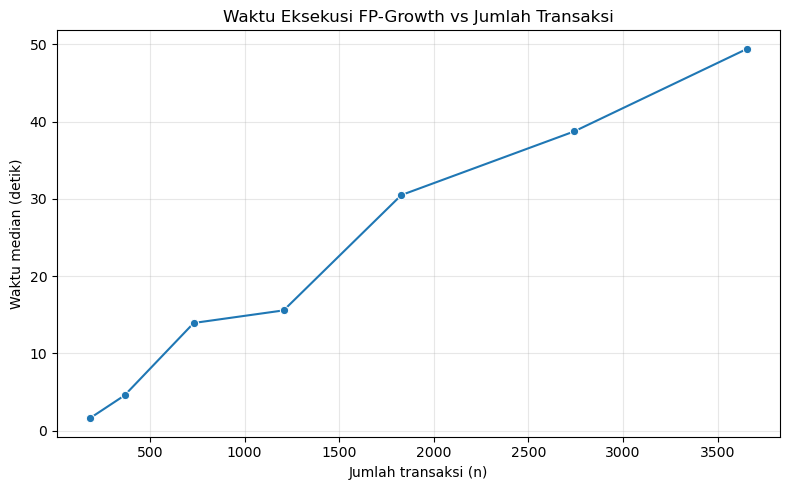

In [18]:
# if 'df_encoded' not in globals():
#     te = TransactionEncoder()
#     src_trx = globals().get('transactions_tabu', globals().get('transactions'))
#     if src_trx is None:
#         raise ValueError("transactions belum terdefinisi; buat dari df sebelum benchmark FP-Growth.")
#     te_ary = te.fit(src_trx).transform(src_trx)
#     df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

drawLine()
print("⏱️ Benchmark FP-Growth vs Ukuran Dataset")
drawLine()

bench_fp = benchmark_fpgrowth(
    df_encoded,
    repeats=5,
    min_support=0.001,  # samakan dengan konfigurasi yang dipakai sebelumnya
    seed=42
)
print(tabulate(bench_fp, headers='keys', tablefmt='grid', showindex=False))

plt.figure(figsize=(8, 5))
sns.lineplot(data=bench_fp, x='n_transactions', y='time_sec_median', marker='o')
plt.title('Waktu Eksekusi FP-Growth vs Jumlah Transaksi')
plt.xlabel('Jumlah transaksi (n)')
plt.ylabel('Waktu median (detik)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## CBP (Conditional Pattern Base)

In [20]:
transactions_tabu_temp = transactions_tabu.copy()

In [19]:
transactions_tabu

[['apples', 'butter', 'eggs', 'potatoes'],
 ['oranges'],
 ['milk', 'onions', 'cereal'],
 ['tomatoes', 'potatoes', 'cereal'],
 ['bananas'],
 ['tomatoes'],
 ['pasta',
  'onions',
  'bread',
  'bananas',
  'coffee',
  'sugar',
  'potatoes',
  'oranges'],
 ['bananas', 'oranges', 'potatoes'],
 ['chicken', 'cereal', 'bananas'],
 ['cheese', 'pasta', 'cereal', 'onions', 'bananas', 'chicken'],
 ['sugar', 'eggs'],
 ['onions', 'cereal', 'cheese'],
 ['cereal', 'coffee', 'bread', 'onions'],
 ['chicken', 'pasta'],
 ['eggs', 'butter', 'bananas', 'chicken', 'tomatoes'],
 ['tea', 'bananas', 'pasta', 'eggs', 'cereal'],
 ['sugar', 'coffee'],
 ['apples', 'tomatoes', 'chicken', 'pasta', 'bread', 'sugar', 'potatoes'],
 ['yogurt', 'butter', 'bananas'],
 ['milk', 'eggs', 'sugar', 'juice', 'tomatoes', 'butter', 'onions'],
 ['coffee', 'bananas'],
 ['onions'],
 ['coffee', 'tea', 'bananas', 'onions', 'juice', 'pasta'],
 ['tea', 'juice', 'cereal', 'butter'],
 ['yogurt', 'juice'],
 ['pasta',
  'onions',
  'chicken'

In [20]:
# Tujuan: Membangun Conditional Pattern Base (CPB) untuk setiap 1-itemset
#          – himpunan jalur prefiks yang muncul bersama item tertentu.
#          CPB ini menjadi masukan untuk menambang pola frekuensi dengan FP-Growth.
from collections import defaultdict

# 1: Hitung frekuensi global setiap item
item_counts = defaultdict(int)
for transaction in transactions_tabu:
    for item in transaction:
        item_counts[item] += 1

# 2: Hapus item di bawah ambang minimum support
min_support = 0.01 * len(transactions_tabu)
item_counts = {item: count for item, count in item_counts.items() if count >= min_support}

print("item_counts:", item_counts)
# 3: Urutkan item yang tersisa secara menurun berdasarkan frekuensi
def sort_items(transactions_tabu):
    return sorted([item for item in transactions_tabu if item in item_counts],
            key=lambda item: (-item_counts[item], item))

sorted_transactions = [sort_items(t) for t in transactions_tabu]

print("sorted_transactions:", sorted_transactions)

item_counts: {'apples': 1377, 'butter': 959, 'eggs': 521, 'potatoes': 972, 'oranges': 970, 'milk': 934, 'onions': 944, 'cereal': 935, 'tomatoes': 1374, 'bananas': 1783, 'pasta': 949, 'bread': 959, 'coffee': 1392, 'sugar': 1400, 'chicken': 1002, 'cheese': 966, 'tea': 942, 'yogurt': 941, 'juice': 530}
sorted_transactions: [['apples', 'potatoes', 'butter', 'eggs'], ['oranges'], ['onions', 'cereal', 'milk'], ['tomatoes', 'potatoes', 'cereal'], ['bananas'], ['tomatoes'], ['bananas', 'sugar', 'coffee', 'potatoes', 'oranges', 'bread', 'pasta', 'onions'], ['bananas', 'potatoes', 'oranges'], ['bananas', 'chicken', 'cereal'], ['bananas', 'chicken', 'cheese', 'pasta', 'onions', 'cereal'], ['sugar', 'eggs'], ['cheese', 'onions', 'cereal'], ['coffee', 'bread', 'onions', 'cereal'], ['chicken', 'pasta'], ['bananas', 'tomatoes', 'chicken', 'butter', 'eggs'], ['bananas', 'pasta', 'tea', 'cereal', 'eggs'], ['sugar', 'coffee'], ['sugar', 'apples', 'tomatoes', 'chicken', 'potatoes', 'bread', 'pasta'], ['b

In [21]:
# 4: FP-Tree
class FPNode:
    def __init__(self, item, count=1):
        self.item = item
        self.count = count
        self.children = {}
        self.parent = None

class FPTree:
    def __init__(self):
        self.root = FPNode(None)
        self.headers = defaultdict(list)

    def insert(self, transaction):
        current = self.root
        for item in transaction:
            if item in current.children:
                current.children[item].count += 1
            else:
                new_node = FPNode(item)
                new_node.parent = current
                current.children[item] = new_node
                self.headers[item].append(new_node)
            current = current.children[item]

    def conditional_pattern_base(self, item):
        patterns = []
        for node in self.headers[item]:
            path = []
            current = node.parent
            while current and current.item is not None:
                path.append(current.item)
                current = current.parent
            if path:
                patterns.append((list(reversed(path)), node.count))
        return patterns


In [22]:
# 5: Isi FP-Tree dengan transaksi yang sudah diurutkan
tree = FPTree()
for transaction in sorted_transactions:
    tree.insert(transaction)

In [23]:
# 6: Tampilkan Conditional Pattern Base untuk setiap 1-itemset yang frekuen
print("\nConditional Pattern Base untuk semua item:")
for item in item_counts.keys():
    cpb = tree.conditional_pattern_base(item)
    print(f"\nItem: {item}")
    if cpb:
        for pattern, count in cpb:
            print(f"  Jalur: {pattern}, Hitungan: {count}")
    else:
        print("  (Tidak ada pola)")


Conditional Pattern Base untuk semua item:

Item: apples
  Jalur: ['sugar'], Hitungan: 25
  Jalur: ['sugar', 'coffee'], Hitungan: 132
  Jalur: ['bananas', 'sugar'], Hitungan: 157
  Jalur: ['coffee'], Hitungan: 20
  Jalur: ['bananas'], Hitungan: 759
  Jalur: ['bananas', 'sugar', 'coffee'], Hitungan: 53
  Jalur: ['bananas', 'coffee'], Hitungan: 130

Item: butter
  Jalur: ['apples', 'potatoes'], Hitungan: 1
  Jalur: ['bananas', 'tomatoes', 'chicken'], Hitungan: 1
  Jalur: ['bananas'], Hitungan: 18
  Jalur: ['sugar', 'tomatoes'], Hitungan: 1
  Jalur: ['bananas', 'tomatoes', 'potatoes'], Hitungan: 1
  Jalur: ['potatoes', 'oranges', 'bread'], Hitungan: 1
  Jalur: ['coffee', 'tomatoes', 'chicken', 'potatoes', 'oranges', 'bread'], Hitungan: 1
  Jalur: ['tomatoes', 'chicken', 'potatoes'], Hitungan: 13
  Jalur: ['bananas', 'potatoes', 'cheese', 'bread'], Hitungan: 1
  Jalur: ['bananas', 'coffee', 'potatoes', 'cheese'], Hitungan: 1
  Jalur: ['coffee', 'cheese'], Hitungan: 1
  Jalur: ['sugar', 'c

In [24]:
# mencari conditional frequent itemset
# Fungsi untuk menambang frequent itemsets dari FP-Tree secara rekursif
def mine_tree(tree, suffix, min_support, frequent_patterns):
    for item in tree.headers:
        new_suffix = suffix.copy()
        new_suffix.add(item)

        # Hitung total support item dari header
        support = sum(node.count for node in tree.headers[item])

        if support >= min_support:
            frequent_patterns[frozenset(new_suffix)] = support

            # Bangun CPB dari node
            cpb = tree.conditional_pattern_base(item)

            # Bangun conditional FP-Tree
            conditional_tree = FPTree()
            for path, count in cpb:
                sorted_path = sorted(
                    [i for i in path],
                    key=lambda i: (-item_counts.get(i, 0), i)
                )
                for _ in range(count):  # Tambahkan sesuai count
                    conditional_tree.insert(sorted_path)

            # Rekursif ke bawah pohon
            mine_tree(conditional_tree, new_suffix, min_support, frequent_patterns)

# Menambang frequent itemsets dari pohon utama
frequent_patterns = {}
mine_tree(tree, set(), min_support, frequent_patterns)

# Tampilkan hasil
print("\nFrequent itemsets yang ditemukan (FP-Growth):")
for itemset, support in frequent_patterns.items():
    print(f"{set(itemset)}: {support}")



Frequent itemsets yang ditemukan (FP-Growth):
{'apples'}: 1377
{'sugar', 'apples'}: 367
{'sugar', 'bananas', 'apples'}: 210
{'coffee', 'apples'}: 335
{'coffee', 'sugar', 'apples'}: 185
{'coffee', 'sugar', 'bananas', 'apples'}: 53
{'coffee', 'bananas', 'apples'}: 183
{'bananas', 'apples'}: 1099
{'potatoes'}: 972
{'potatoes', 'apples'}: 291
{'sugar', 'potatoes', 'apples'}: 85
{'sugar', 'potatoes', 'bananas', 'apples'}: 44
{'coffee', 'potatoes', 'apples'}: 74
{'coffee', 'potatoes', 'bananas', 'apples'}: 37
{'potatoes', 'bananas', 'apples'}: 195
{'tomatoes', 'potatoes'}: 624
{'tomatoes', 'potatoes', 'sugar'}: 101
{'tomatoes', 'potatoes', 'apples'}: 106
{'tomatoes', 'potatoes', 'bananas', 'apples'}: 39
{'coffee', 'tomatoes', 'potatoes'}: 112
{'tomatoes', 'potatoes', 'bananas'}: 124
{'potatoes', 'bananas'}: 344
{'potatoes', 'sugar'}: 266
{'potatoes', 'bananas', 'sugar'}: 83
{'coffee', 'potatoes'}: 275
{'coffee', 'potatoes', 'bananas'}: 84
{'coffee', 'potatoes', 'sugar'}: 153
{'chicken', 'po

## Implementasi Assosiasi

In [25]:
frequent_itemsets

,support,itemsets
0,0.376641,(apples)
1,0.265864,(potatoes)
2,0.262309,(butter)
3,0.142505,(eggs)
4,0.265317,(oranges)
...,...,...
11647,0.001641,"(tea, juice, bananas, yogurt, bread)"
11648,0.001094,"(tea, juice, milk, yogurt, bread)"
11649,0.001094,"(tea, juice, bread, sugar, chicken)"
11650,0.001094,"(tea, juice, coffee, bread, chicken)"



Aturan Asosiasi:
                           antecedents        consequents   support  \
0                              (sugar)           (apples)  0.100383   
1                             (apples)            (sugar)  0.100383   
2                             (coffee)           (apples)  0.091630   
3                             (apples)           (coffee)  0.091630   
4                            (bananas)           (apples)  0.300602   
...                                ...                ...       ...   
50186    (coffee, tea, juice, chicken)     (sugar, bread)  0.001094   
50187       (tea, juice, sugar, bread)  (coffee, chicken)  0.001094   
50188     (chicken, tea, juice, bread)    (coffee, sugar)  0.001094   
50189  (coffee, juice, chicken, bread)       (tea, sugar)  0.001094   
50190   (chicken, juice, sugar, bread)      (coffee, tea)  0.001094   

       confidence      lift  
0        0.262143  0.696002  
1        0.266521  0.696002  
2        0.240661  0.638966  
3        

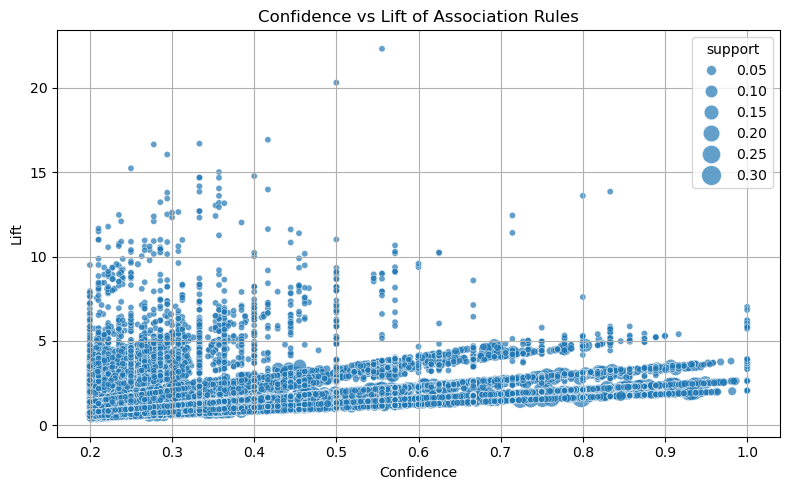

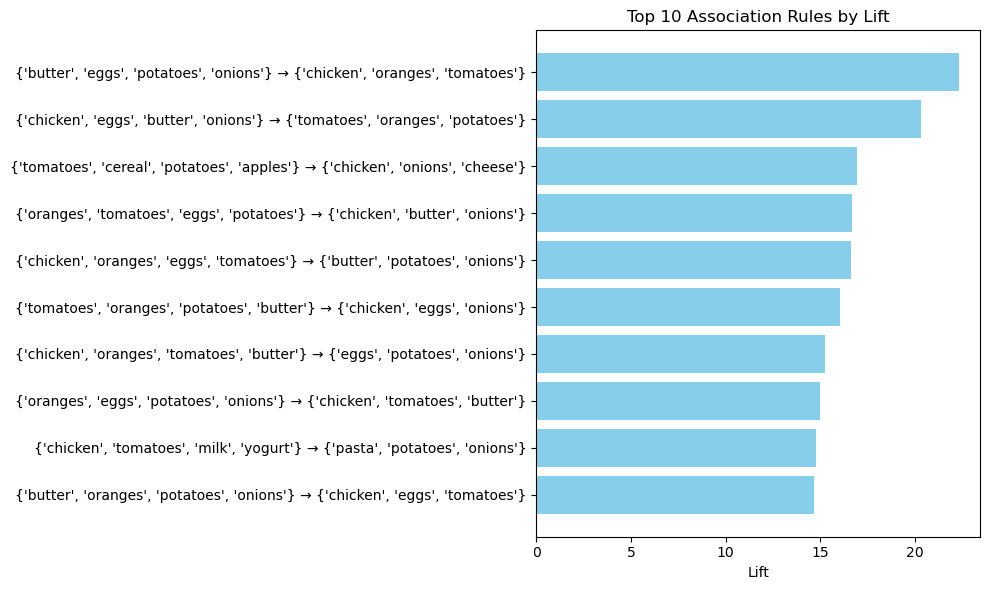

In [26]:
# mencari aturan asosiasi
from mlxtend.frequent_patterns import association_rules

# Buat aturan asosiasi dengan minimum confidence 0.1
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.2)

print("\nAturan Asosiasi:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

# Visualisasi scatter plot confidence vs lift
plt.figure(figsize=(8, 5))
sns.scatterplot(data=rules, x='confidence', y='lift', size='support', sizes=(20, 200), alpha=0.7)
plt.title('Confidence vs Lift of Association Rules')
plt.xlabel('Confidence')
plt.ylabel('Lift')
plt.grid(True)
plt.tight_layout()
plt.show()

# Visualisasi top 10 aturan berdasarkan lift
top_rules = rules.nlargest(10, 'lift')
plt.figure(figsize=(10, 6))
y_pos = range(len(top_rules))
plt.barh(y_pos, top_rules['lift'], color='skyblue')
plt.yticks(y_pos, [f"{set(row['antecedents'])} → {set(row['consequents'])}" for _, row in top_rules.iterrows()])
plt.xlabel('Lift')
plt.title('Top 10 Association Rules by Lift')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


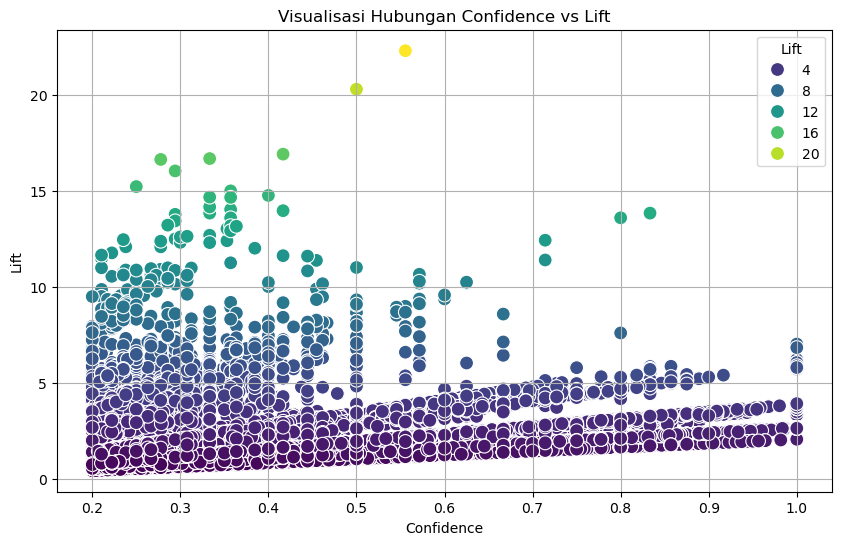

In [27]:
# Visualisasi hubungan lift dan confidence
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rules, x='confidence', y='lift', hue='lift', palette='viridis', s=100)
plt.title('Visualisasi Hubungan Confidence vs Lift')
plt.xlabel('Confidence')
plt.ylabel('Lift')
plt.legend(title='Lift')
plt.grid(True)
plt.show()


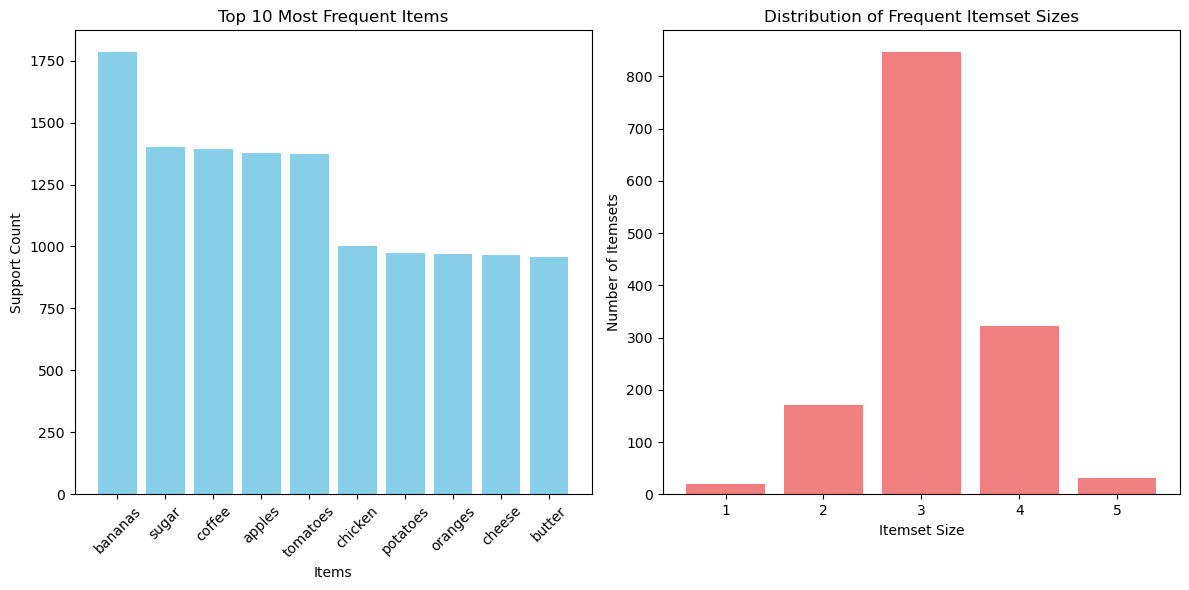


=== ANALISIS KESIMPULAN ===
Total transaksi: 3656
Total item unik: 19
Total frequent itemsets: 1390
Total association rules: 50191

Top 10 Association Rules (berdasarkan lift):
butter, eggs, potatoes, onions → chicken, oranges, tomatoes
  Support: 0.001, Confidence: 0.556, Lift: 22.320

chicken, eggs, butter, onions → tomatoes, oranges, potatoes
  Support: 0.001, Confidence: 0.500, Lift: 20.311

tomatoes, cereal, potatoes, apples → chicken, onions, cheese
  Support: 0.001, Confidence: 0.417, Lift: 16.926

oranges, tomatoes, eggs, potatoes → chicken, butter, onions
  Support: 0.001, Confidence: 0.333, Lift: 16.694

chicken, oranges, eggs, tomatoes → butter, potatoes, onions
  Support: 0.001, Confidence: 0.278, Lift: 16.648

tomatoes, oranges, potatoes, butter → chicken, eggs, onions
  Support: 0.001, Confidence: 0.294, Lift: 16.049

chicken, oranges, tomatoes, butter → eggs, potatoes, onions
  Support: 0.001, Confidence: 0.250, Lift: 15.233

oranges, eggs, potatoes, onions → chicken, t

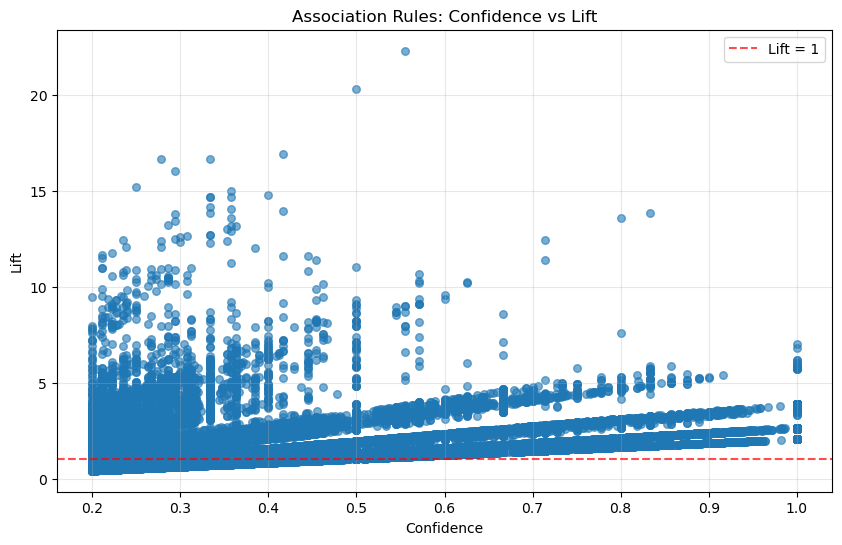

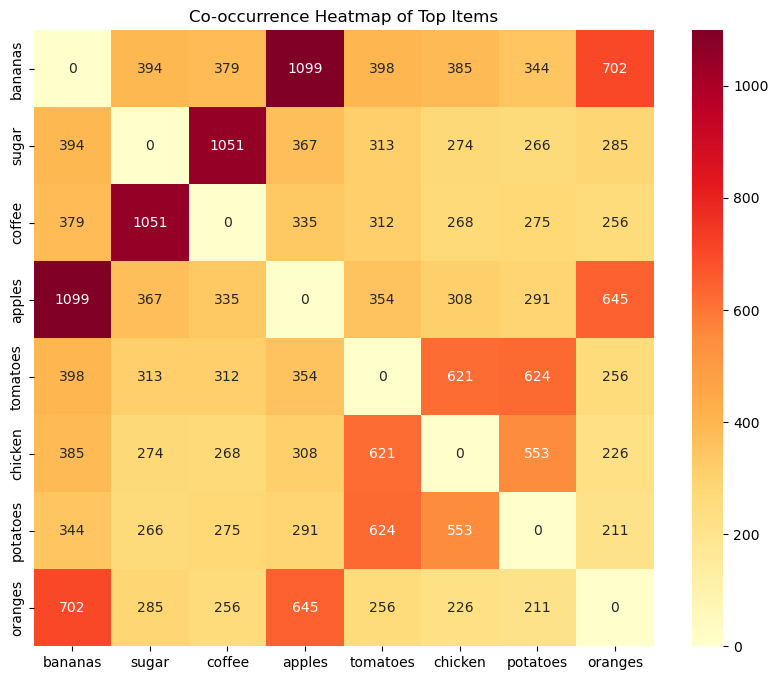


=== STATISTIK RINGKASAN ===
Rata-rata confidence: 0.392
Rata-rata lift: 1.665
Rata-rata support: 0.005
Jumlah rules dengan lift > 2: 12924
Jumlah rules dengan confidence > 0.8: 2783

=== REKOMENDASI BISNIS ===
1. Item yang sering dibeli bersama:
   - apples, sugar (support: 367)
   - apples, bananas, sugar (support: 210)
   - apples, coffee (support: 335)
   - apples, coffee, sugar (support: 185)
   - apples, bananas, coffee, sugar (support: 53)
   - apples, bananas, coffee (support: 183)
   - apples, bananas (support: 1099)
   - apples, potatoes (support: 291)

2. Strategi Cross-selling berdasarkan rules dengan lift tinggi:
   - Jika customer membeli chicken, potatoes, pasta, cheese, rekomendasikan eggs, tomatoes
     (Confidence: 32.0%, Lift: 5.79)
   - Jika customer membeli chicken, potatoes, pasta, apples, rekomendasikan eggs, tomatoes
     (Confidence: 28.6%, Lift: 5.17)
   - Jika customer membeli pasta, potatoes, bananas, cheese, rekomendasikan eggs, tomatoes
     (Confidence: 3

In [28]:
# Tambahkan cell baru untuk analisis dan visualisasi kesimpulan
from collections import Counter

# 1. Visualisasi Top 10 Frequent Items
item_support = {}
for itemset, support in frequent_patterns.items():
    if len(itemset) == 1:
        item_support[list(itemset)[0]] = support

top_items = sorted(item_support.items(), key=lambda x: x[1], reverse=True)[:10]

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
items, supports = zip(*top_items)
plt.bar(items, supports, color='skyblue')
plt.title('Top 10 Most Frequent Items')
plt.xlabel('Items')
plt.ylabel('Support Count')
plt.xticks(rotation=45)

# 2. Distribusi Ukuran Itemsets
itemset_sizes = [len(itemset) for itemset in frequent_patterns.keys()]
size_counts = Counter(itemset_sizes)

plt.subplot(1, 2, 2)
sizes = list(size_counts.keys())
counts = list(size_counts.values())
plt.bar(sizes, counts, color='lightcoral')
plt.title('Distribution of Frequent Itemset Sizes')
plt.xlabel('Itemset Size')
plt.ylabel('Number of Itemsets')

plt.tight_layout()
plt.show()

# 3. Analisis Top Association Rules
print("\n=== ANALISIS KESIMPULAN ===")
print(f"Total transaksi: {len(transactions)}")
print(f"Total item unik: {len(set([item for transaction in transactions for item in transaction]))}")
print(f"Total frequent itemsets: {len(frequent_patterns)}")
print(f"Total association rules: {len(rules)}")

# Top 10 rules berdasarkan lift
top_rules = rules.nlargest(10, 'lift')
print("\nTop 10 Association Rules (berdasarkan lift):")
for idx, rule in top_rules.iterrows():
    antecedents = ', '.join(list(rule['antecedents']))
    consequents = ', '.join(list(rule['consequents']))
    print(f"{antecedents} → {consequents}")
    print(f"  Support: {rule['support']:.3f}, Confidence: {rule['confidence']:.3f}, Lift: {rule['lift']:.3f}")
    print()

# 4. Visualisasi Confidence vs Lift
plt.figure(figsize=(10, 6))
plt.scatter(rules['confidence'], rules['lift'], alpha=0.6, s=30)
plt.xlabel('Confidence')
plt.ylabel('Lift')
plt.title('Association Rules: Confidence vs Lift')
plt.axhline(y=1, color='red', linestyle='--', alpha=0.7, label='Lift = 1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. Heatmap untuk item co-occurrence
from itertools import combinations

# Buat matrix co-occurrence untuk top items
top_item_names = [item for item, _ in top_items[:8]]  # Ambil 8 item teratas
co_occurrence = np.zeros((len(top_item_names), len(top_item_names)))

for i, item1 in enumerate(top_item_names):
    for j, item2 in enumerate(top_item_names):
        if i != j:
            # Cari support untuk pasangan item
            pair = frozenset([item1, item2])
            if pair in frequent_patterns:
                co_occurrence[i][j] = frequent_patterns[pair]

plt.figure(figsize=(10, 8))
sns.heatmap(co_occurrence, 
            xticklabels=top_item_names, 
            yticklabels=top_item_names,
            annot=True, 
            fmt='.0f',
            cmap='YlOrRd')
plt.title('Co-occurrence Heatmap of Top Items')
plt.show()

# 6. Summary Statistics
print("\n=== STATISTIK RINGKASAN ===")
print(f"Rata-rata confidence: {rules['confidence'].mean():.3f}")
print(f"Rata-rata lift: {rules['lift'].mean():.3f}")
print(f"Rata-rata support: {rules['support'].mean():.3f}")
print(f"Jumlah rules dengan lift > 2: {len(rules[rules['lift'] > 2])}")
print(f"Jumlah rules dengan confidence > 0.8: {len(rules[rules['confidence'] > 0.8])}")

# 7. Rekomendasi Bisnis
print("\n=== REKOMENDASI BISNIS ===")
print("1. Item yang sering dibeli bersama:")
for itemset, support in list(frequent_patterns.items())[:10]:
    if len(itemset) >= 2:
        items_str = ', '.join(sorted(list(itemset)))
        print(f"   - {items_str} (support: {support})")

print("\n2. Strategi Cross-selling berdasarkan rules dengan lift tinggi:")
high_lift_rules = rules[rules['lift'] > 5].head(5)
for idx, rule in high_lift_rules.iterrows():
    antecedents = ', '.join(list(rule['antecedents']))
    consequents = ', '.join(list(rule['consequents']))
    print(f"   - Jika customer membeli {antecedents}, rekomendasikan {consequents}")
    print(f"     (Confidence: {rule['confidence']:.1%}, Lift: {rule['lift']:.2f})")